In [1]:
import os

# ── auto-detect project root (works on ANY computer!) ─────────────────
NOTEBOOK_DIR = os.getcwd()

if os.path.exists(os.path.join(NOTEBOOK_DIR, "..", "data")):
    PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
else:
    PROJECT_ROOT = NOTEBOOK_DIR

PARQUET_PATH = os.path.join(PROJECT_ROOT, "data", "processed", "flights_clean.parquet")

print(f" Project root : {PROJECT_ROOT}")
print(f" Parquet path : {PARQUET_PATH}")
print(f" Path exists  : {os.path.exists(PARQUET_PATH)}")

 Project root : D:\airline_pipeline
 Parquet path : D:\airline_pipeline\data\processed\flights_clean.parquet
 Path exists  : True


In [2]:
import os
import time
import pandas as pd
import dask.dataframe as dd
from dask.distributed import Client

print(" Libraries imported!")

 Libraries imported!


In [3]:
# connect to deployed Dask on Kubernetes
# exactly like Lab 3!
print("Connecting to Dask on Kubernetes...")

deployed_client = Client("tcp://localhost:8786")
print(deployed_client)

print(f"\n Connected to Kubernetes Dask cluster!")
print(f" Dashboard : {deployed_client.dashboard_link}")
print(f" Workers   : {len(deployed_client.scheduler_info()['workers'])}")

Connecting to Dask on Kubernetes...
<Client: 'tcp://10.244.0.21:8786' processes=2 threads=8, memory=23.37 GiB>

 Connected to Kubernetes Dask cluster!
 Dashboard : http://localhost:8787/status
 Workers   : 2


C:\Users\easho\anaconda3\envs\pyspark_env\Lib\site-packages\distributed\client.py:1612: VersionMismatchWarning: Mismatched versions found

+-------------+-----------------+-----------------+-----------------+
| Package     | Client          | Scheduler       | Workers         |
+-------------+-----------------+-----------------+-----------------+
| cloudpickle | 3.1.2           | 3.1.1           | 3.1.1           |
| lz4         | 4.4.5           | 4.3.3           | 4.3.3           |
| msgpack     | 1.1.2           | 1.1.0           | 1.1.0           |
| numpy       | 2.4.3           | 2.2.2           | 2.2.2           |
| python      | 3.11.15.final.0 | 3.10.12.final.0 | 3.10.12.final.0 |
| toolz       | 1.1.0           | 0.12.0          | 0.12.0          |
| tornado     | 6.5.5           | 6.4.2           | 6.4.2           |
+-------------+-----------------+-----------------+-----------------+
  warnings.warn(version_module.VersionMismatchWarning(msg[0]["warning"]))


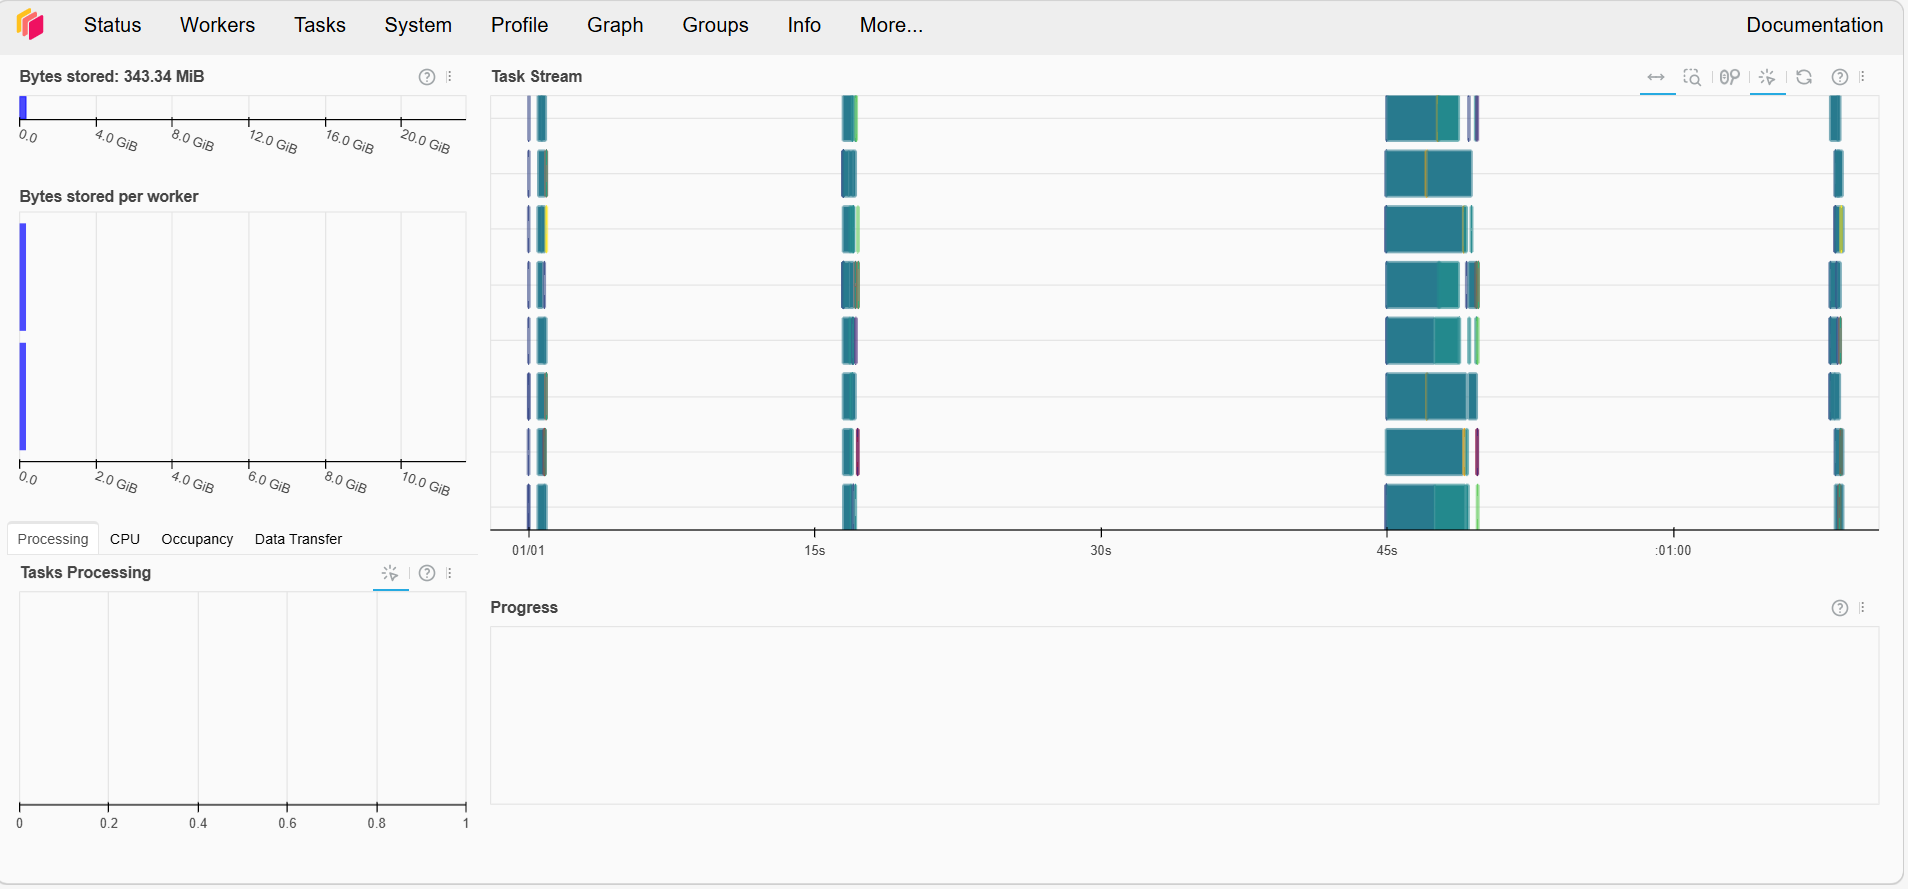

In [5]:
PARQUET_PATH = r"D:\airline_pipeline\data\processed\flights_clean.parquet"

print("=" * 55)
print("RUNNING AIRLINE PIPELINE ON KUBERNETES")
print("=" * 55)

# load data locally then send to K8s workers
# same approach as Lab 3!
print(" Loading Parquet data...")
pdf = pd.read_parquet(
    PARQUET_PATH,
    columns=["Year", "Month", "Reporting_Airline",
             "Origin", "Dest", "ArrDelay",
             "DepDelay", "Cancelled", "Distance"]
)
print(f" Loaded {len(pdf):,} rows into pandas")

# convert to Dask DataFrame with 12 partitions
# so task distribution is visible on dashboard!
ddf_k8s = dd.from_pandas(pdf, npartitions=12)
print(f" Converted to Dask with {ddf_k8s.npartitions} partitions")
print(f" Data sent to Kubernetes workers!")

RUNNING AIRLINE PIPELINE ON KUBERNETES
 Loading Parquet data...
 Loaded 27,657,704 rows into pandas
 Converted to Dask with 12 partitions
 Data sent to Kubernetes workers!


In [6]:
print("=" * 55)
print("ANALYSIS RUNNING ON KUBERNETES PODS")
print("=" * 55)
print(" Watch the Dask dashboard → http://localhost:8787\n")

start = time.time()

# Q1 — airline performance
print(" Q1: Airline delay performance...")
airline_result = ddf_k8s.groupby("Reporting_Airline")["ArrDelay"] \
    .mean().compute()
print(f" Q1 done — {len(airline_result)} airlines")

# Q2 — monthly patterns
print(" Q2: Monthly patterns...")
monthly_result = ddf_k8s.groupby(["Year", "Month"])["ArrDelay"] \
    .mean().compute()
print(f" Q2 done — {len(monthly_result)} month records")

# Q3 — route analysis
print(" Q3: Route analysis...")
route_result = ddf_k8s.groupby(["Origin", "Dest"])["ArrDelay"] \
    .mean().compute()
print(f" Q3 done — {len(route_result):,} routes")

# Q4 — cancellation rate
print(" Q4: Cancellation rate per airline...")
cancel_result = ddf_k8s.groupby("Reporting_Airline")["Cancelled"] \
    .mean().compute()
print(f" Q4 done — {len(cancel_result)} airlines")

total_time = round(time.time() - start, 2)

print("=" * 55)
print(f" All queries completed on Kubernetes!")
print(f"  Total time : {total_time} seconds")
print("=" * 55)

ANALYSIS RUNNING ON KUBERNETES PODS
 Watch the Dask dashboard → http://localhost:8787

 Q1: Airline delay performance...


C:\Users\easho\anaconda3\envs\pyspark_env\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 474.78 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


 Q1 done — 17 airlines
 Q2: Monthly patterns...


C:\Users\easho\anaconda3\envs\pyspark_env\Lib\site-packages\dask\dataframe\dask_expr\_groupby.py:1561: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self._meta = self.obj._meta.groupby(
C:\Users\easho\anaconda3\envs\pyspark_env\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 263.78 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


 Q2 done — 96 month records
 Q3: Route analysis...


C:\Users\easho\anaconda3\envs\pyspark_env\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 791.31 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


 Q3 done — 7,966 routes
 Q4: Cancellation rate per airline...


C:\Users\easho\anaconda3\envs\pyspark_env\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 369.28 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


 Q4 done — 17 airlines
 All queries completed on Kubernetes!
  Total time : 104.74 seconds


In [7]:
print("=" * 55)
print("RESULTS FROM KUBERNETES CLUSTER")
print("=" * 55)

print("\n  TOP 5 WORST AIRLINES (avg arrival delay):")
print(airline_result.sort_values(ascending=False).head())

print("\n WORST MONTHS (avg arrival delay):")
print(monthly_result.sort_values(ascending=False).head())

print("\n TOP 5 WORST ROUTES:")
route_filtered = route_result[route_result.index.map(
    lambda x: True
)]
print(route_result.sort_values(ascending=False).head())

print("\n HIGHEST CANCELLATION RATES:")
print((cancel_result * 100).round(2).sort_values(
    ascending=False).head())

print("=" * 55)
print(" Pipeline ran successfully on Kubernetes!")
print("=" * 55)

RESULTS FROM KUBERNETES CLUSTER

  TOP 5 WORST AIRLINES (avg arrival delay):
Reporting_Airline
F9    15.899089
B6    14.439155
G4    13.765475
AA    12.664464
NK     9.961942
Name: ArrDelay, dtype: float64

 WORST MONTHS (avg arrival delay):
Year  Month
2024  7        17.502897
2025  7        16.834638
2023  7        16.177078
2025  6        15.283821
2023  6        14.044993
Name: ArrDelay, dtype: float64

 TOP 5 WORST ROUTES:
Origin  Dest
GJT     ATL     1254.0
BUR     FLL      922.0
CVG     CLE      817.0
JFK     LGA      755.0
PSP     CLT      716.0
Name: ArrDelay, dtype: float64

 HIGHEST CANCELLATION RATES:
Reporting_Airline
YV    3.32
YX    3.17
OH    2.75
9E    2.69
B6    2.31
Name: Cancelled, dtype: float64
 Pipeline ran successfully on Kubernetes!


In [8]:
print("=" * 55)
print("KUBERNETES DEPLOYMENT SUMMARY")
print("=" * 55)
print(f" Cluster        : Minikube (local K8s)")
print(f" Kubernetes ver : v1.35.1")
print(f" Helm ver       : v3.14.4")
print(f" Dask image     : 2025.1.0")
print(f" Scheduler pods : 1")
print(f" Worker pods    : 2")
print(f" Data processed : {len(pdf):,} rows")
print(f" Partitions     : 12")
print(f" Pipeline time  : {total_time} seconds")
print(f" Dashboard      : http://localhost:8787")
print("=" * 55)
print(" Step 8 — Kubernetes COMPLETE!")
print(" Ready for Step 9 — Technical Report!")

# close client
deployed_client.close()
print("\n Kubernetes client closed cleanly!")

KUBERNETES DEPLOYMENT SUMMARY
 Cluster        : Minikube (local K8s)
 Kubernetes ver : v1.35.1
 Helm ver       : v3.14.4
 Dask image     : 2025.1.0
 Scheduler pods : 1
 Worker pods    : 2
 Data processed : 27,657,704 rows
 Partitions     : 12
 Pipeline time  : 104.74 seconds
 Dashboard      : http://localhost:8787
 Step 8 — Kubernetes COMPLETE!
 Ready for Step 9 — Technical Report!

 Kubernetes client closed cleanly!


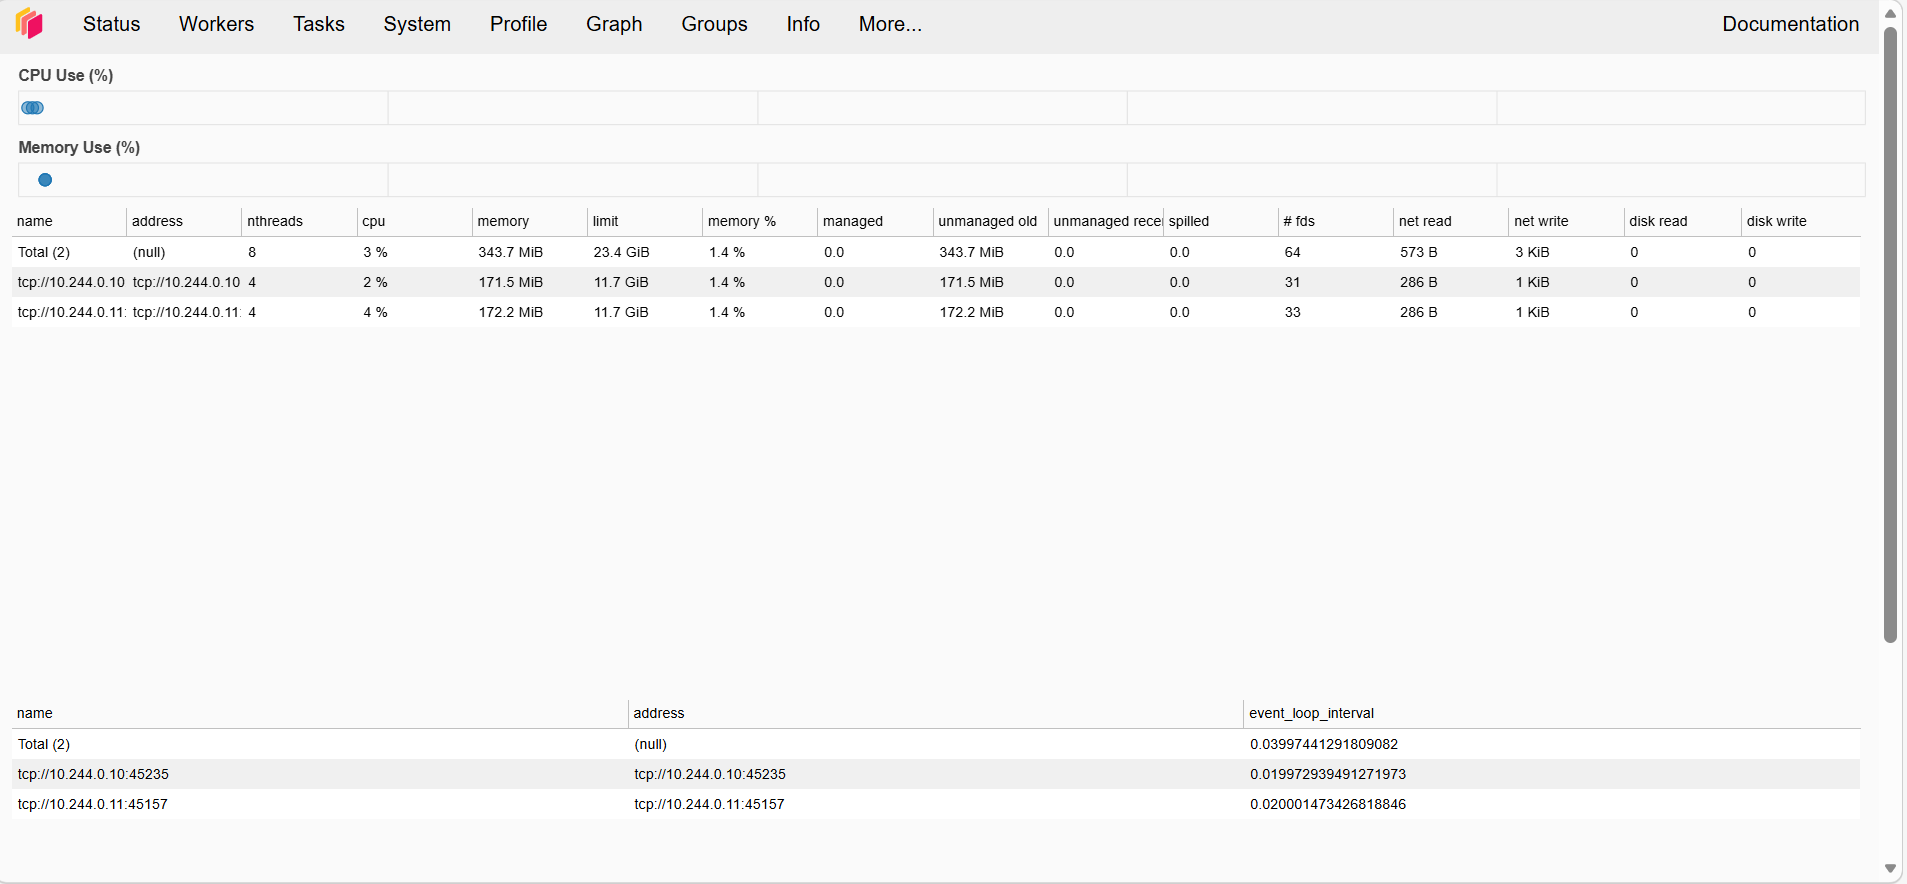

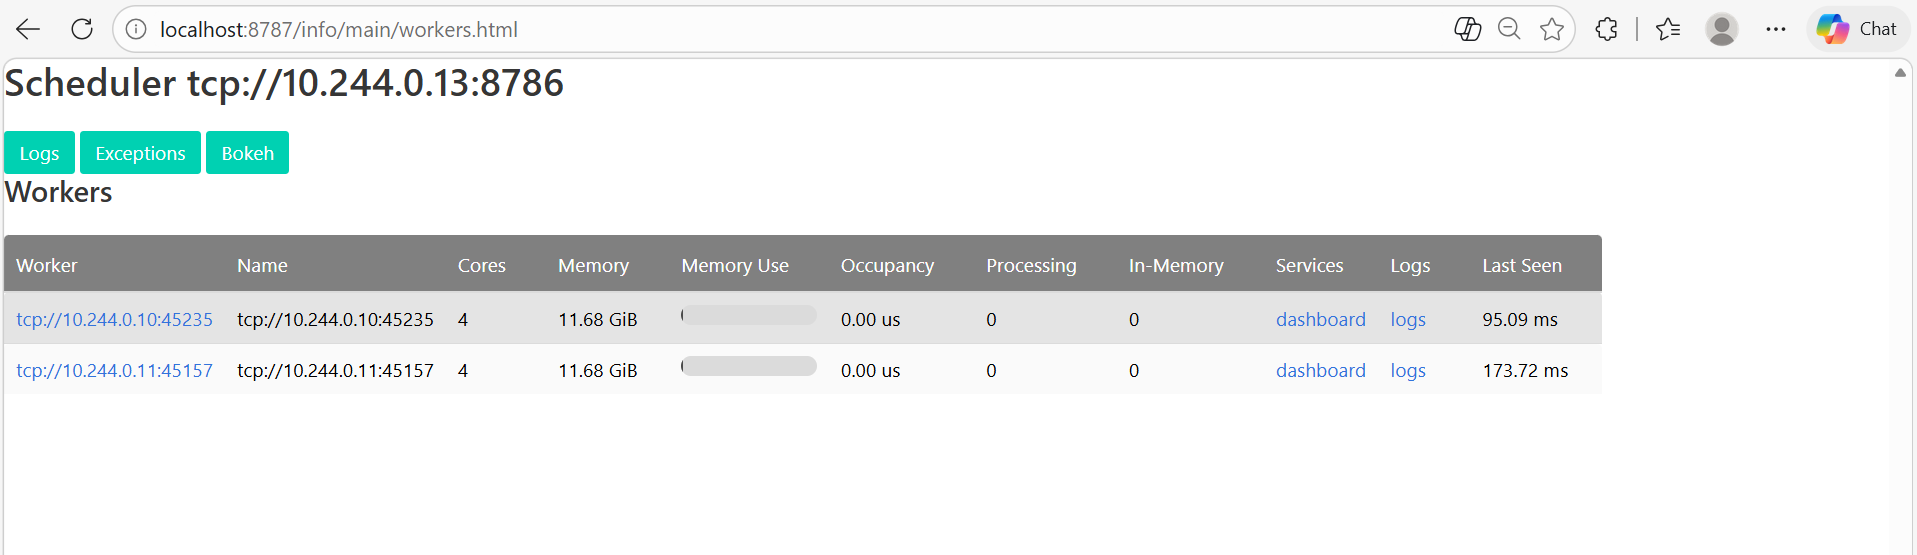

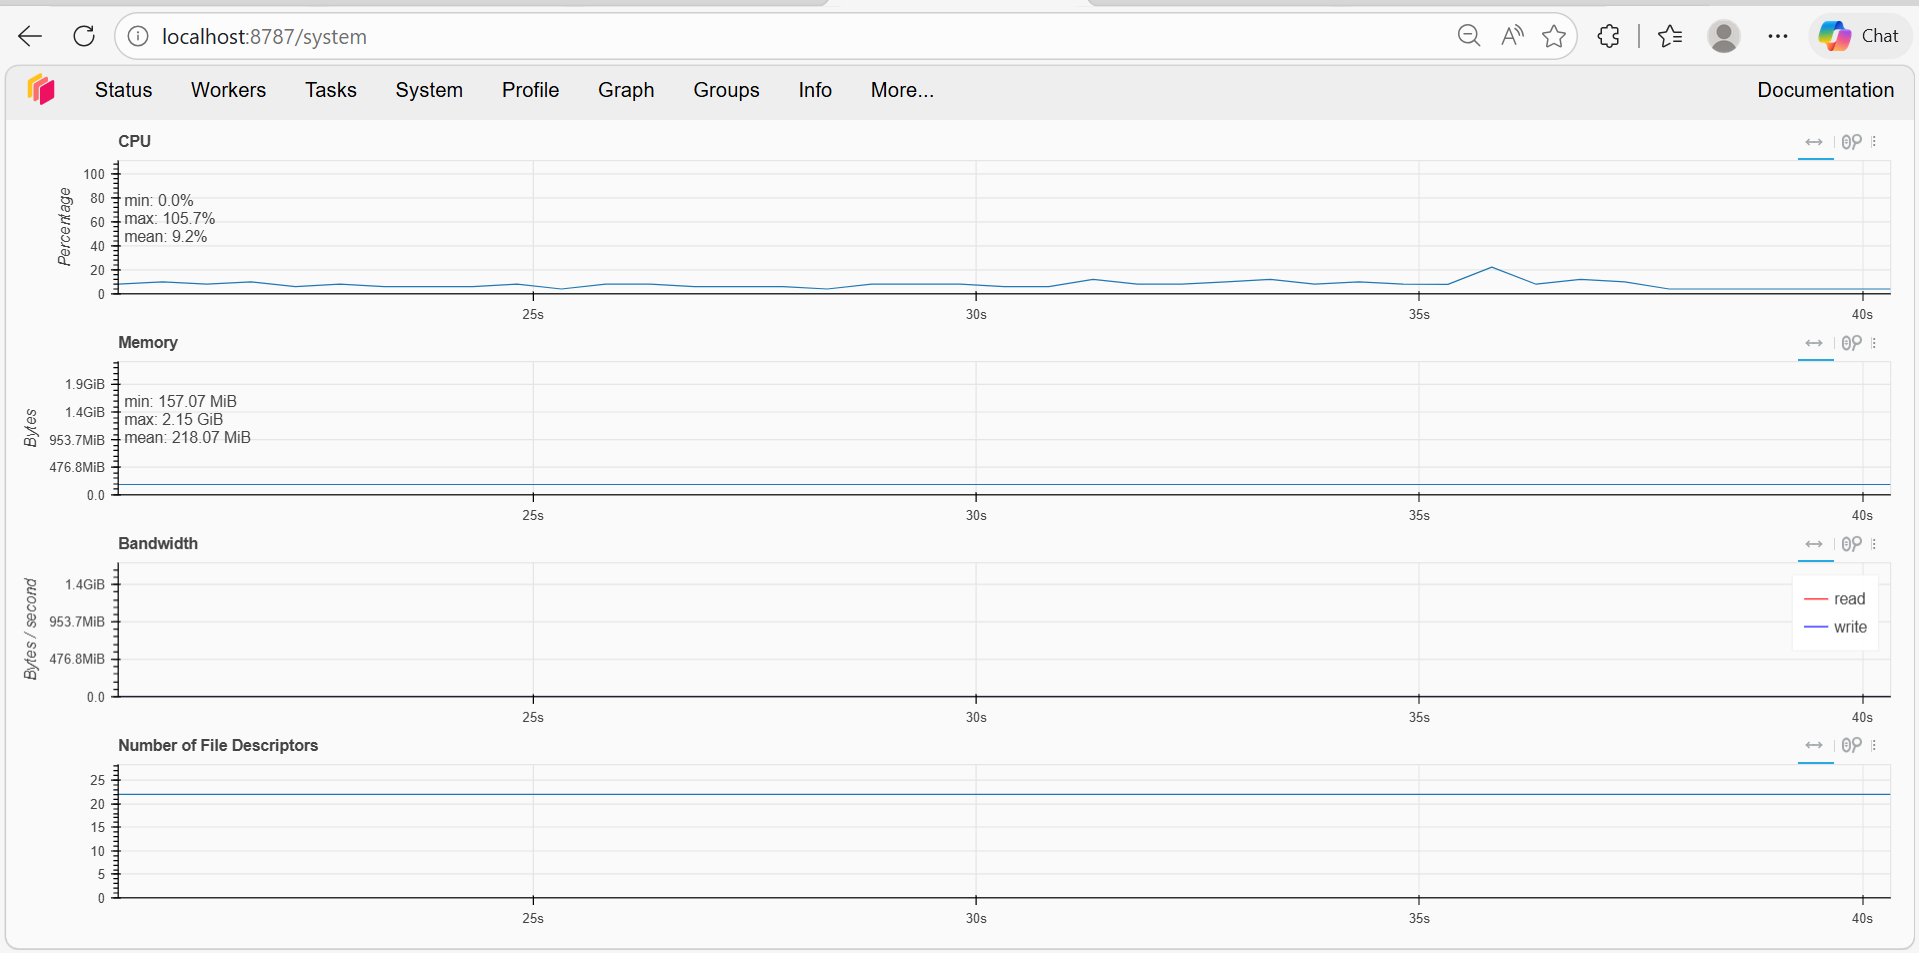

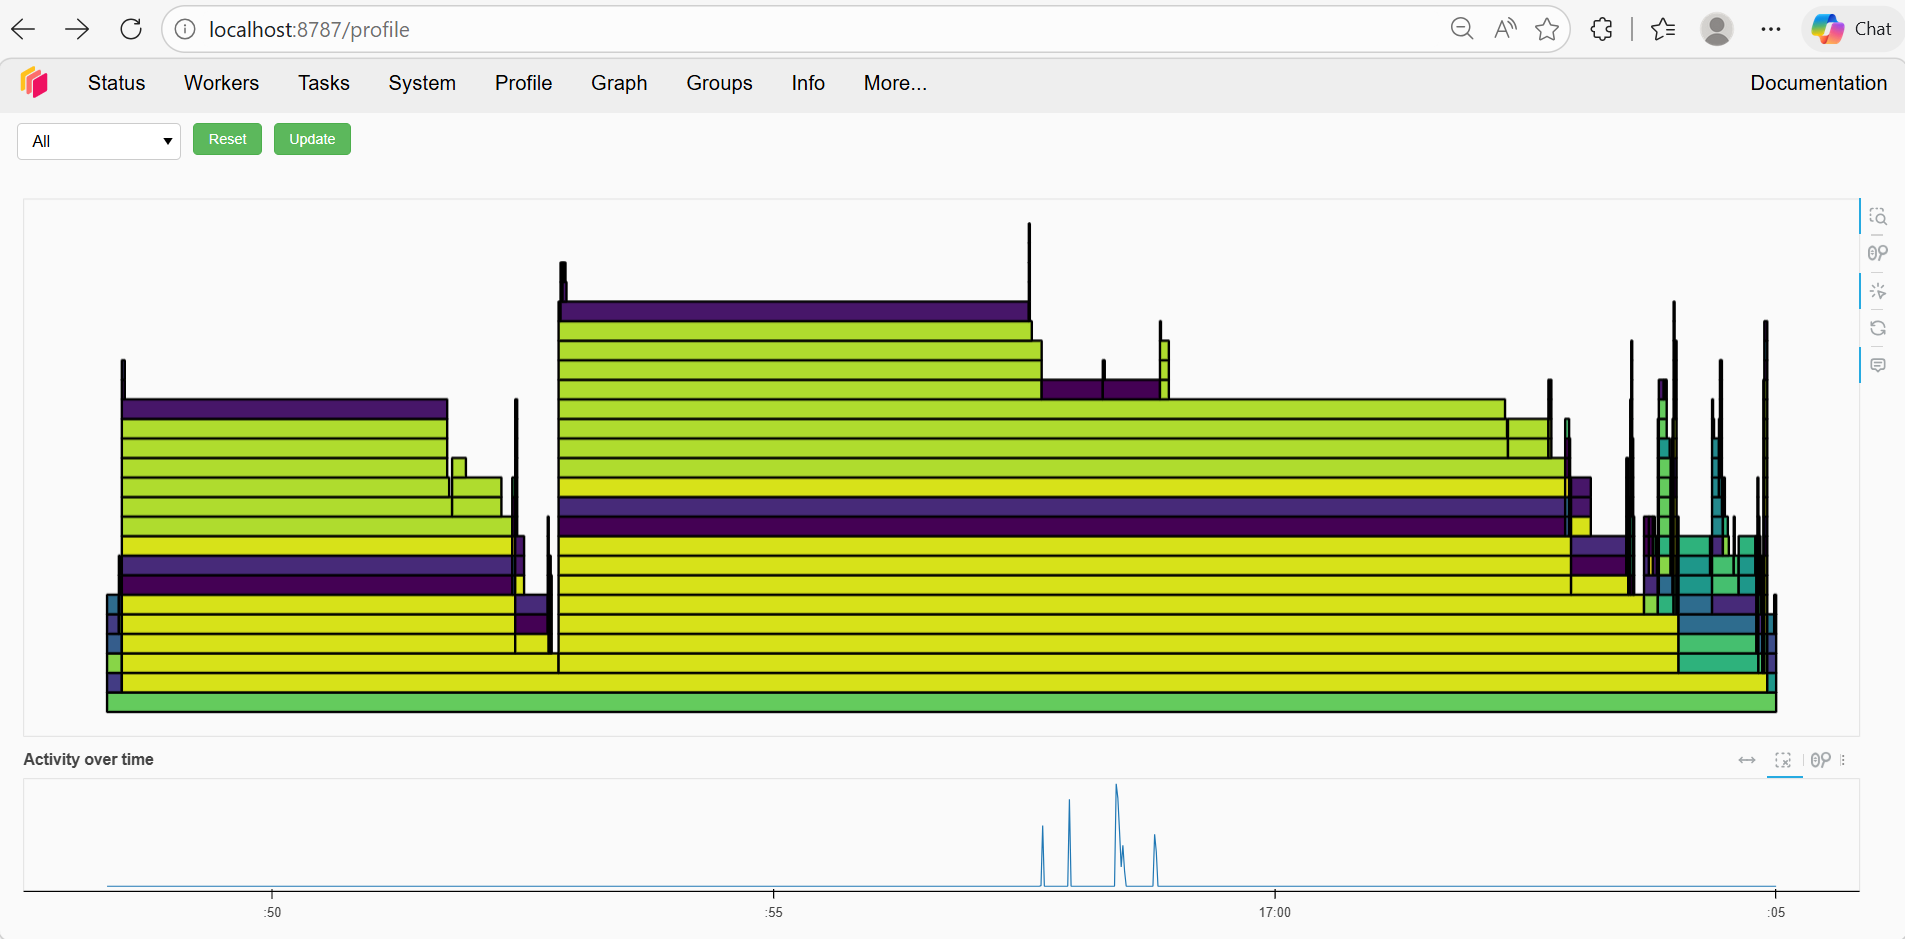